In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0532.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0282.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_1401.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0914.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0691.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0972.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0818.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0463.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0930.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_1323.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_1347.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_1354.jpg
/kaggle/input/brain-tumor-update-dataset/Training/pituitary/Tr-pi_0704.jpg
/kaggle/input/brain-tumor

In [2]:
import tensorflow as tf
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

In [4]:
Train_df = '/kaggle/input/brain-tumor-update-dataset/Training'

filepaths = []
labels = []
folds = os.listdir(Train_df)
for fold in folds:
    FoldPath = os.path.join(Train_df, fold)
    files = os.listdir(FoldPath)
    for file in tqdm(files):
        filepath = os.path.join(FoldPath,file)
        filepaths.append(filepath)
        labels.append(fold)

100%|██████████| 1321/1321 [00:00<00:00, 645766.39it/s]


In [5]:
print(len(filepaths))
print(len(labels))

5712
5712


In [6]:
print(labels[-1])

glioma


In [7]:
print(np.unique(labels))

['glioma' 'meningioma' 'notumor' 'pituitary']


In [8]:
df_train = pd.DataFrame(
    data = {
        'filepath': filepaths,
        'label': labels
    }
)

In [9]:
df_train.head()

,filepath,label
0,/kaggle/input/brain-tumor-update-dataset/Train...,pituitary
1,/kaggle/input/brain-tumor-update-dataset/Train...,pituitary
2,/kaggle/input/brain-tumor-update-dataset/Train...,pituitary
3,/kaggle/input/brain-tumor-update-dataset/Train...,pituitary
4,/kaggle/input/brain-tumor-update-dataset/Train...,pituitary


In [10]:
color = ['#9AA6B2','#BCCCDC','#D9EAFD','#F8FAFC']

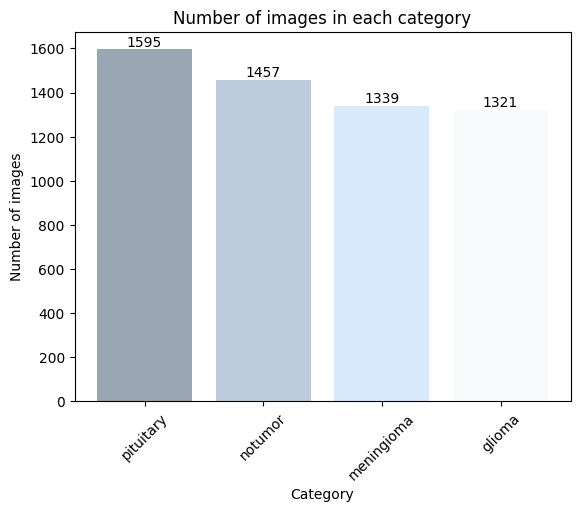

In [11]:
fig, ax = plt.subplots()
bars = ax.bar(df_train['label'].unique(), df_train['label'].value_counts(),color=color)
ax.bar_label(bars)
plt.title('Number of images in each category')
plt.xlabel('Category')
plt.ylabel('Number of images')
plt.xticks(rotation=45)

plt.show()

In [12]:
df_train.sample(5)

,filepath,label
1700,/kaggle/input/brain-tumor-update-dataset/Train...,notumor
3269,/kaggle/input/brain-tumor-update-dataset/Train...,meningioma
561,/kaggle/input/brain-tumor-update-dataset/Train...,pituitary
5465,/kaggle/input/brain-tumor-update-dataset/Train...,glioma
5460,/kaggle/input/brain-tumor-update-dataset/Train...,glioma


In [13]:
Test_df = '/kaggle/input/brain-tumor-update-dataset/Testing'

filepaths = []
labels = []
folds = os.listdir(Test_df)
for fold in folds:
    FoldPath = os.path.join(Test_df, fold)
    files = os.listdir(FoldPath)
    for file in tqdm(files):
        filepath = os.path.join(FoldPath,file)
        filepaths.append(filepath)
        labels.append(fold)

100%|██████████| 300/300 [00:00<00:00, 483586.16it/s]


In [14]:
print(len(filepaths))
print(len(labels))

1311
1311


In [15]:
print(np.unique(labels))

['glioma' 'meningioma' 'notumor' 'pituitary']


In [16]:
df_test = pd.DataFrame(
    data = {
        'filepath': filepaths,
        'label': labels
    }
)

In [17]:
df_test.head()

,filepath,label
0,/kaggle/input/brain-tumor-update-dataset/Testi...,pituitary
1,/kaggle/input/brain-tumor-update-dataset/Testi...,pituitary
2,/kaggle/input/brain-tumor-update-dataset/Testi...,pituitary
3,/kaggle/input/brain-tumor-update-dataset/Testi...,pituitary
4,/kaggle/input/brain-tumor-update-dataset/Testi...,pituitary


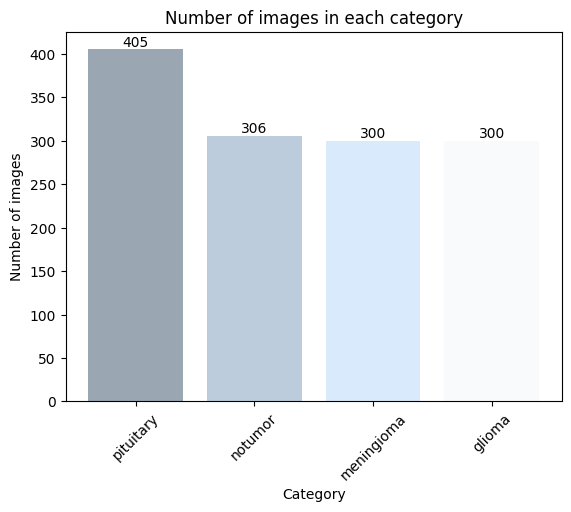

In [18]:
fig, ax = plt.subplots()
bars = ax.bar(df_test['label'].unique(), df_test['label'].value_counts(),color=color)
ax.bar_label(bars)
plt.title('Number of images in each category')
plt.xlabel('Category')
plt.ylabel('Number of images')
plt.xticks(rotation=45)

plt.show()

In [19]:
valid_ts, df_test = train_test_split(df_test, test_size=0.5, random_state=42)

In [20]:
tr_gen = ImageDataGenerator(rescale=1/255)
ts_gen = ImageDataGenerator(rescale=1/255)
batchsize = 32
img_size = (224,224)

In [21]:
gen_train = tr_gen.flow_from_dataframe(df_train, x_col='filepath', y_col='label', target_size=img_size, class_mode='categorical', batch_size=batchsize, shuffle=True,color_mode='rgb')
gen_valid = ts_gen.flow_from_dataframe(valid_ts, x_col='filepath', y_col='label', target_size=img_size, class_mode='categorical', batch_size=batchsize, shuffle=True,color_mode='rgb')
gen_test = ts_gen.flow_from_dataframe(df_test, x_col='filepath', y_col='label', target_size=img_size, class_mode='categorical', batch_size=batchsize, shuffle=False ,color_mode='rgb')

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


In [22]:
class_dict = gen_train.class_indices

In [23]:
Model = Sequential([
    Conv2D(64, kernel_size= (3,3), activation='relu', input_shape=(img_size[0],img_size[1],3)),
    Conv2D(64, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, kernel_size= (3,3), activation='relu'),
    Conv2D(128, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(265, kernel_size= (3,3), activation='relu'),
    Conv2D(265, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3), activation='relu'),
    Conv2D(512, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(512, kernel_size= (3,3), activation='relu'),
    Conv2D(512, kernel_size= (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(64, activation='relu'),
    Dropout(0,3),
    Dense(4, activation='softmax') ])

In [24]:
Model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
history = Model.fit(
    gen_train, 
    epochs=20, 
    validation_data=gen_valid, 
    verbose=1, 
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 149s 633ms/step - accuracy: 0.4108 - loss: 1.1895 - val_accuracy: 0.6885 - val_loss: 0.7549
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 374ms/step - accuracy: 0.7643 - loss: 0.6185 - val_accuracy: 0.7496 - val_loss: 0.6189
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 375ms/step - accuracy: 0.8350 - loss: 0.4420 - val_accuracy: 0.7969 - val_loss: 0.4890
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 375ms/step - accuracy: 0.8649 - loss: 0.3604 - val_accuracy: 0.8595 - val_loss: 0.3396
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 375ms/step - accuracy: 0.9021 - loss: 0.2645 - val_accuracy: 0.8840 - val_loss: 0.3003
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 376ms/step - accuracy: 0.9397 - loss: 0.1838 - val_accuracy: 0.9069 - val_loss: 0.2256
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 376ms/step - accuracy: 0.9457 - loss: 0.1499 - val_accuracy: 0.9084 - val_loss: 0.2256
Epoch 8/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 68s 376ms/step - accuracy: 0.9500 - loss: 

In [26]:
print(Model.evaluate(gen_train))
print(Model.evaluate(gen_valid))
print(Model.evaluate(gen_test))

179/179 ━━━━━━━━━━━━━━━━━━━━ 27s 148ms/step - accuracy: 0.9999 - loss: 0.0018
[0.0016712191281840205, 0.9998249411582947]
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.9839 - loss: 0.0440
[0.04413323849439621, 0.9847328066825867]
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.9780 - loss: 0.1527
[0.13144373893737793, 0.9786585569381714]


In [28]:
Model.save('Model m.h5')

In [29]:
preds = Model.predict(gen_test)
y_pred = np.argmax(preds, axis=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step


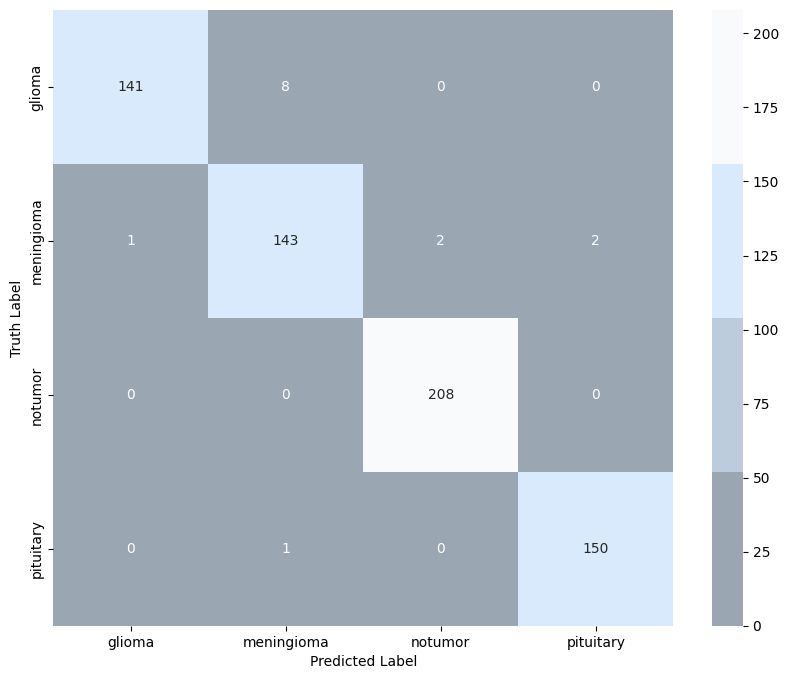

In [30]:
cm = confusion_matrix(gen_test.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

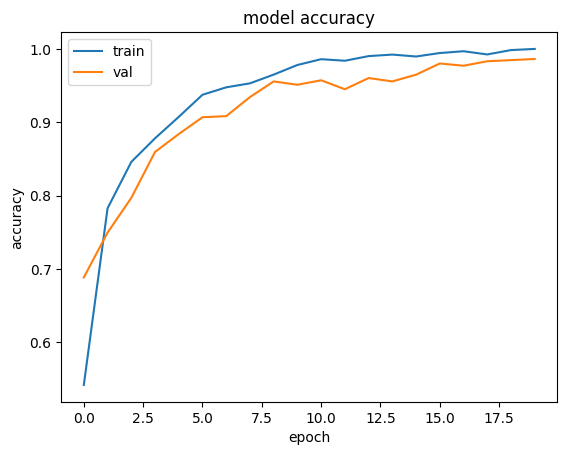

In [31]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

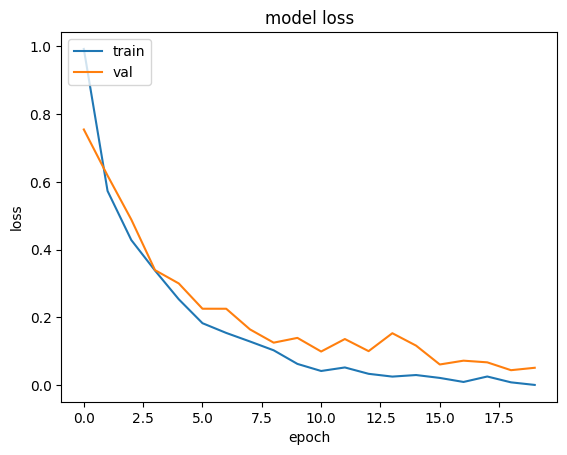

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [33]:
def predict(img_path):

    
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((224, 224))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = Model.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


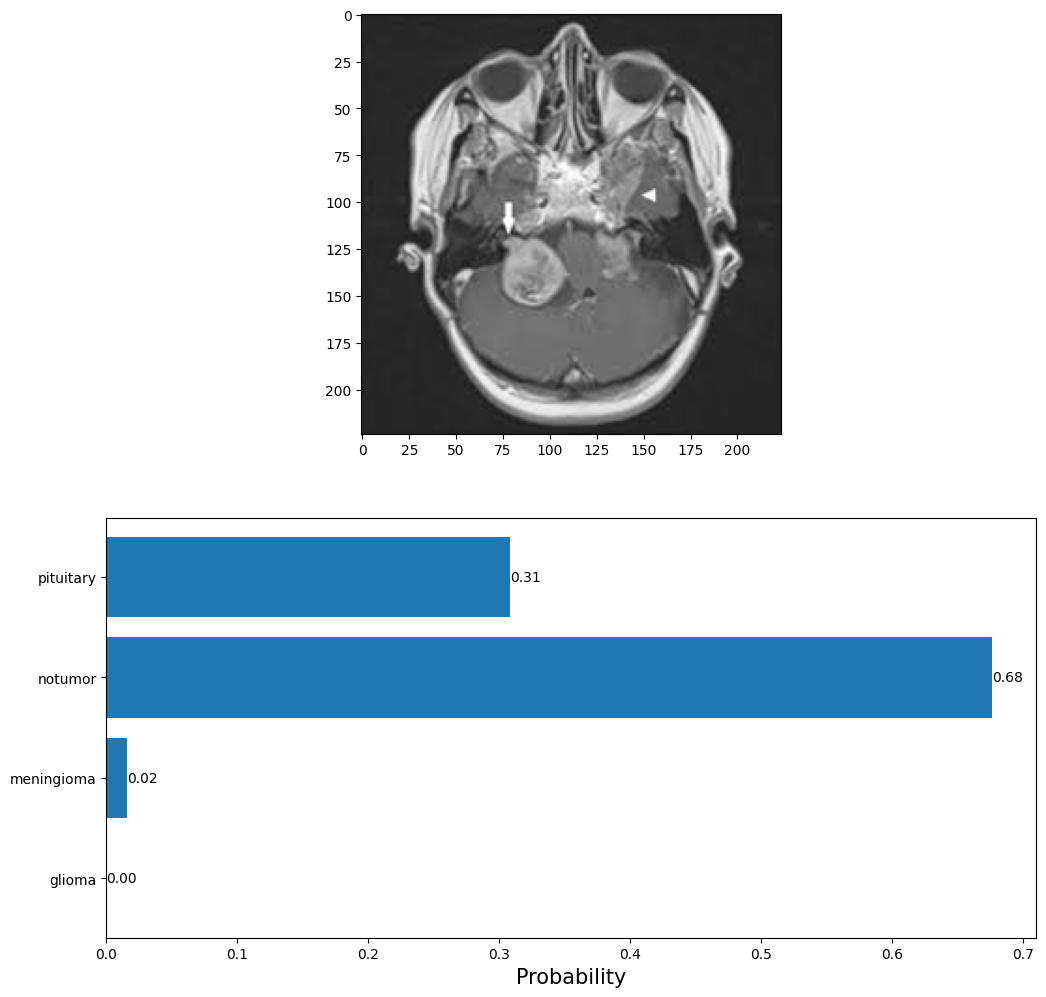

In [34]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/meningioma/Te-meTr_0002.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


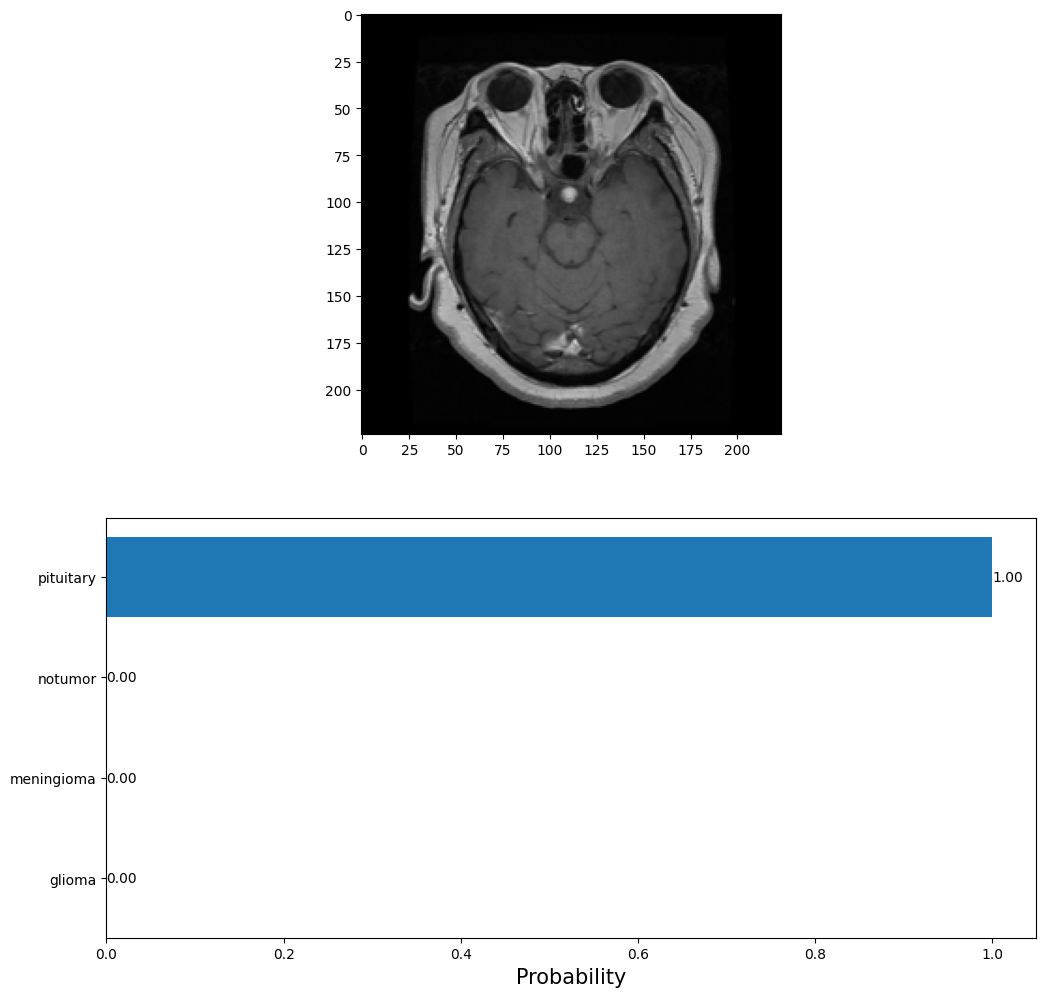

In [35]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/pituitary/Te-pi_0010.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


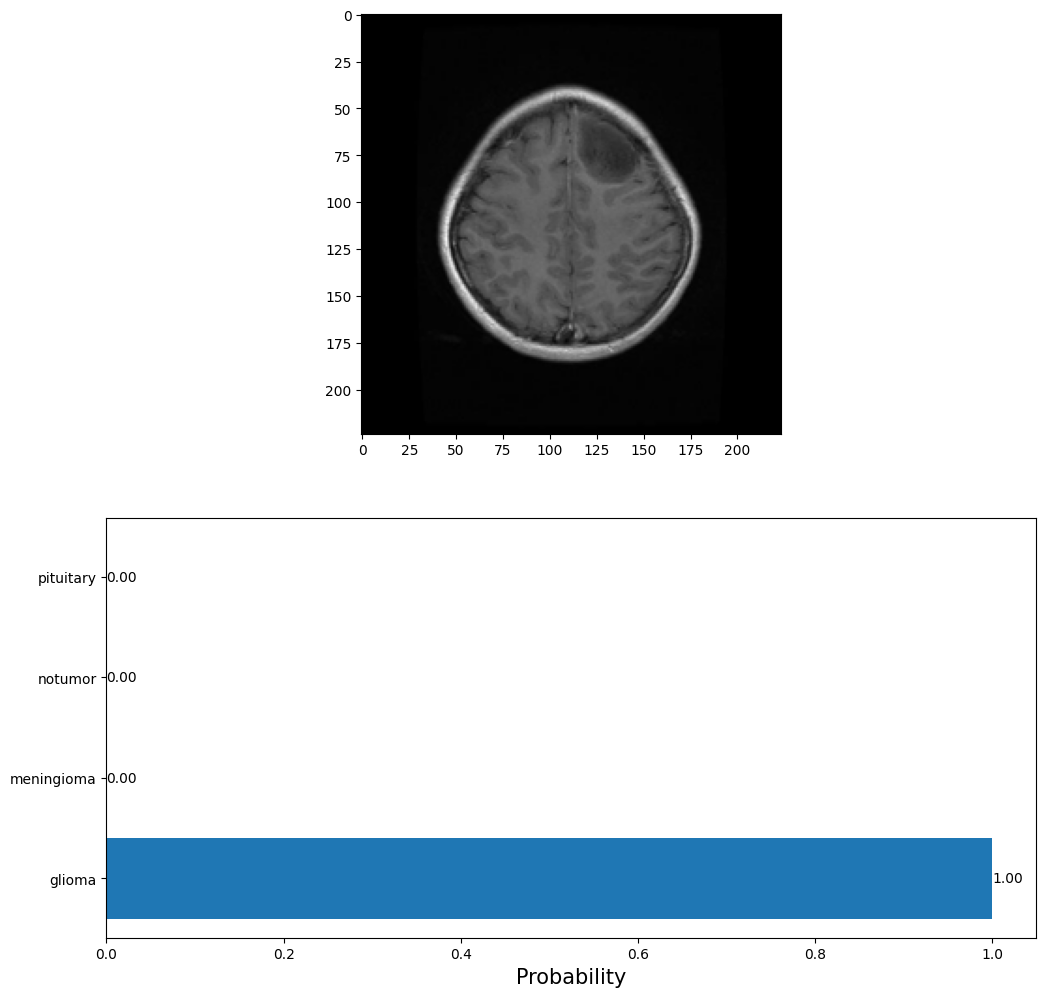

In [36]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/glioma/Te-glTr_0005.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


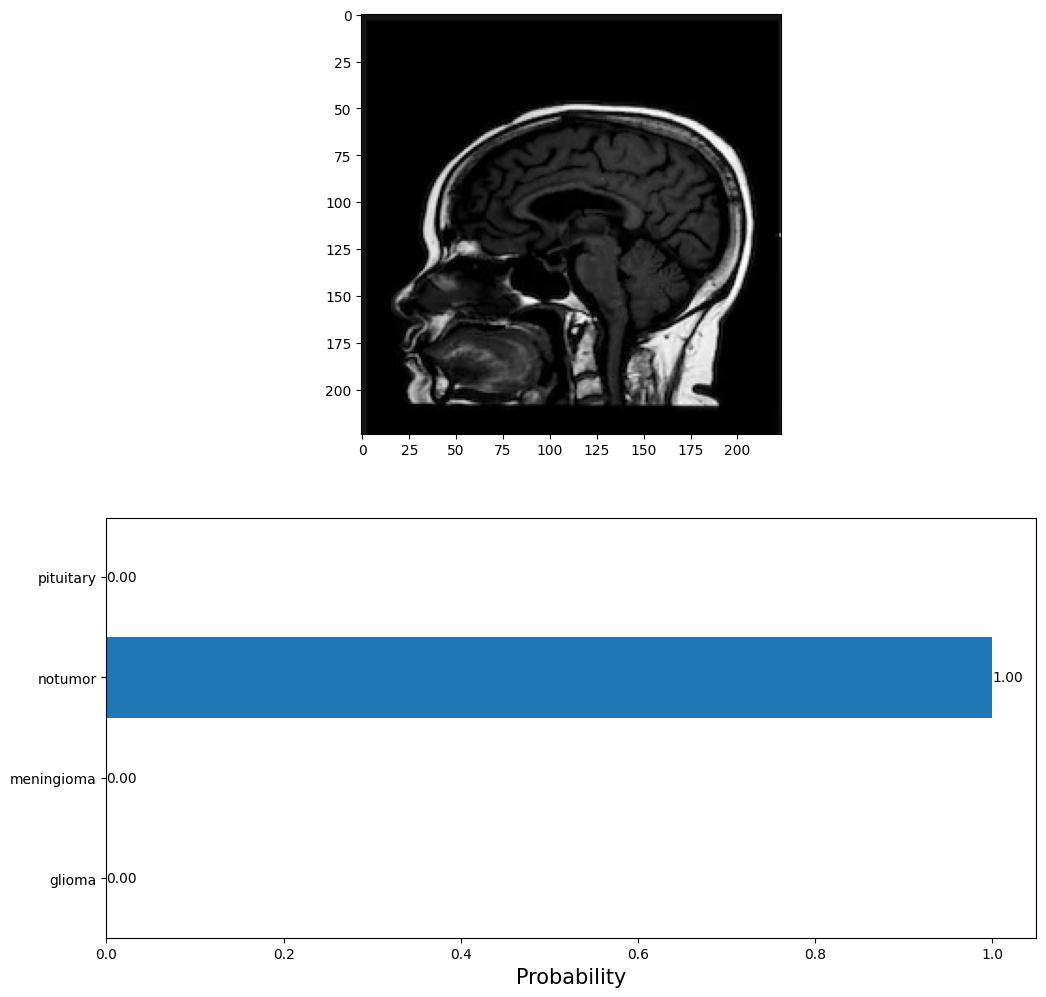

In [37]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/notumor/Te-noTr_0004.jpg')

In [38]:
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights="imagenet",
    input_shape=(img_size[0],img_size[1],3),
    pooling='max',
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [39]:
ModelPretrained = Sequential([
    base_model,
    
    Dense(256 , activation='relu'),
    Dropout(0,3),
    Dense(4, activation='softmax')
    
])
ModelPretrained.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [40]:
history_Final = ModelPretrained.fit(
    gen_train, 
    epochs=5, 
    validation_data=gen_valid, 
    verbose=1, 
    
)

Epoch 1/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 236s 709ms/step - accuracy: 0.8053 - loss: 1.1380 - val_accuracy: 0.2611 - val_loss: 1.6996
Epoch 2/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 52s 286ms/step - accuracy: 0.9742 - loss: 0.0778 - val_accuracy: 0.3099 - val_loss: 2.1277
Epoch 3/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 51s 283ms/step - accuracy: 0.9867 - loss: 0.0373 - val_accuracy: 0.5985 - val_loss: 1.2251
Epoch 4/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 52s 284ms/step - accuracy: 0.9905 - loss: 0.0305 - val_accuracy: 0.8718 - val_loss: 0.4405
Epoch 5/5
179/179 ━━━━━━━━━━━━━━━━━━━━ 51s 284ms/step - accuracy: 0.9940 - loss: 0.0187 - val_accuracy: 0.9756 - val_loss: 0.1022


In [41]:
train_score = ModelPretrained.evaluate(gen_train, verbose=1)
valid_score = ModelPretrained.evaluate(gen_valid, verbose=1)
test_score = ModelPretrained.evaluate(gen_test, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1]*100:.2f}%")
print('-' * 20)
print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1]*100:.2f}%")
print('-' * 20)
print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1]*100:.2f}%")

179/179 ━━━━━━━━━━━━━━━━━━━━ 19s 105ms/step - accuracy: 0.9903 - loss: 0.0259
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.9754 - loss: 0.1165
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.9891 - loss: 0.0338
Train Loss: 0.0260
Train Accuracy: 99.07%
--------------------
Validation Loss: 0.1022
Validation Accuracy: 97.56%
--------------------
Test Loss: 0.0436
Test Accuracy: 98.63%


In [42]:
ModelPretrained.save('Model Final Brain Tumor.h5')

In [43]:
preds = ModelPretrained.predict(gen_test)
y_pred = np.argmax(preds, axis=1)

21/21 ━━━━━━━━━━━━━━━━━━━━ 18s 512ms/step


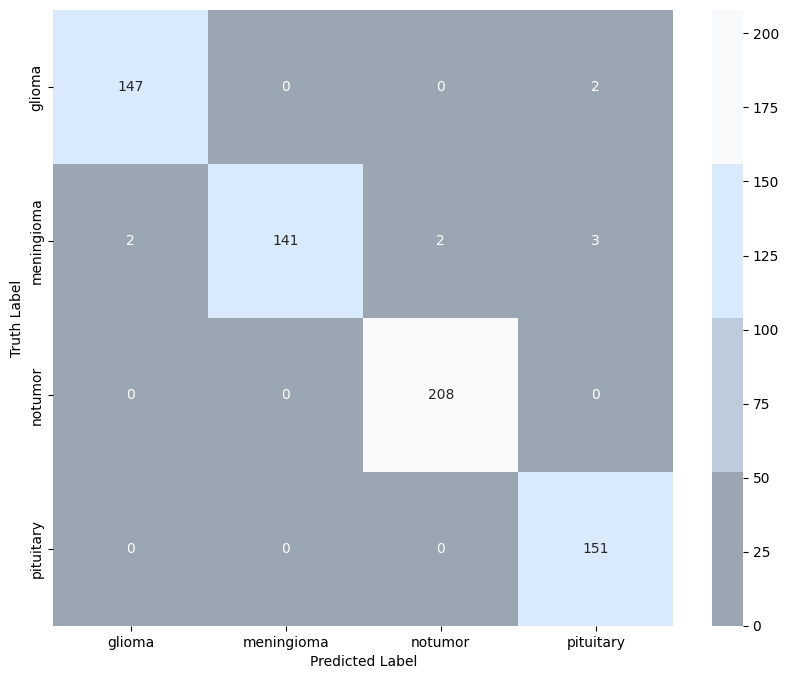

In [44]:
cm = confusion_matrix(gen_test.classes, y_pred)
labels = list(class_dict.keys())
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap=color, xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('Truth Label')
plt.show()

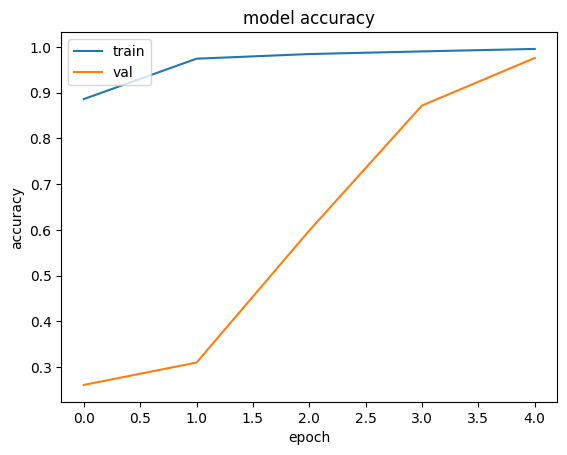

In [45]:
plt.plot(history_Final.history['accuracy'])
plt.plot(history_Final.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

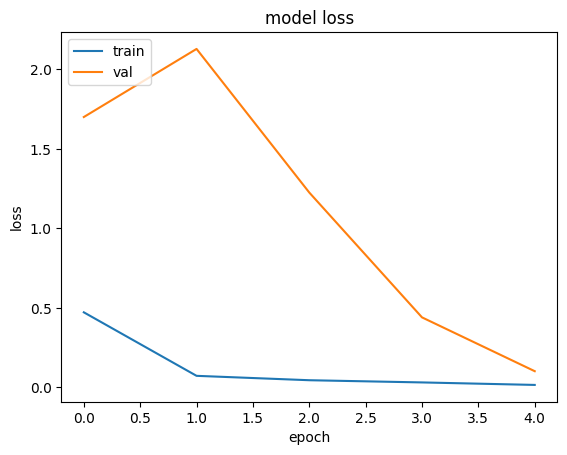

In [46]:
plt.plot(history_Final.history['loss'])
plt.plot(history_Final.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')

In [48]:
def predict(img_path):

    
    label = list(class_dict.keys())
    plt.figure(figsize=(12, 12))
    img = Image.open(img_path)
    resized_img = img.resize((224, 224))
    img = np.asarray(resized_img)
    img = np.expand_dims(img, axis=0)
    img = img / 255
    predictions = ModelPretrained.predict(img)
    probs = list(predictions[0])
    labels = label
    plt.subplot(2, 1, 1)
    plt.imshow(resized_img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Probability', fontsize=15)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


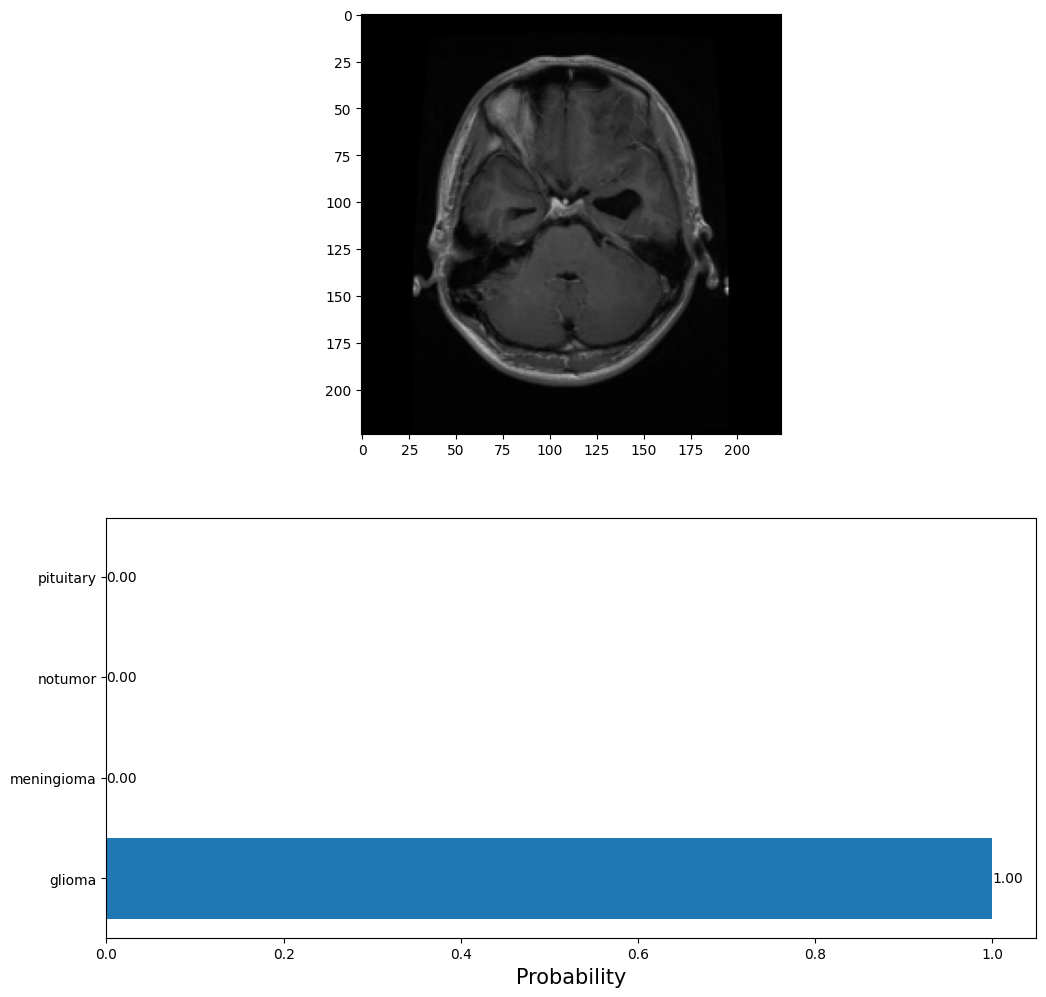

In [49]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/glioma/Te-glTr_0004.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


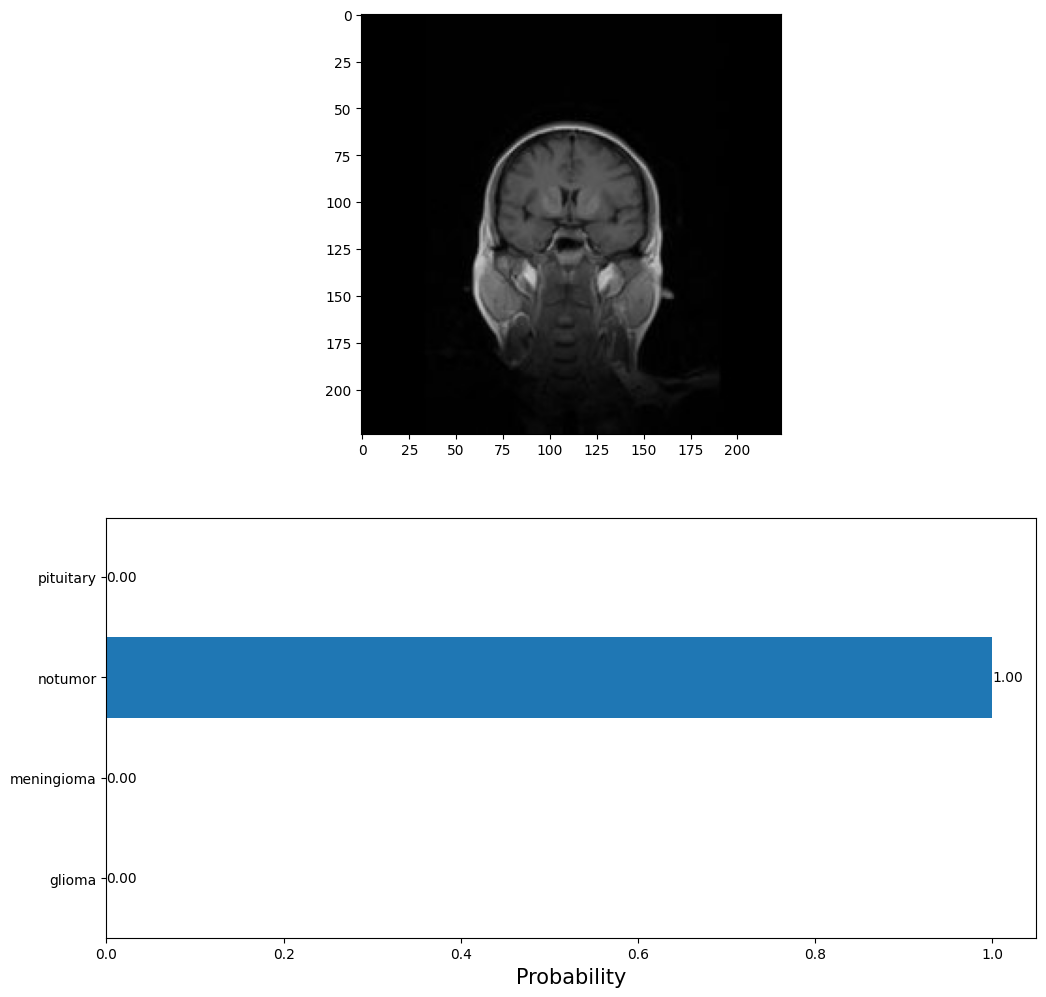

In [55]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/notumor/Te-no_0029.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


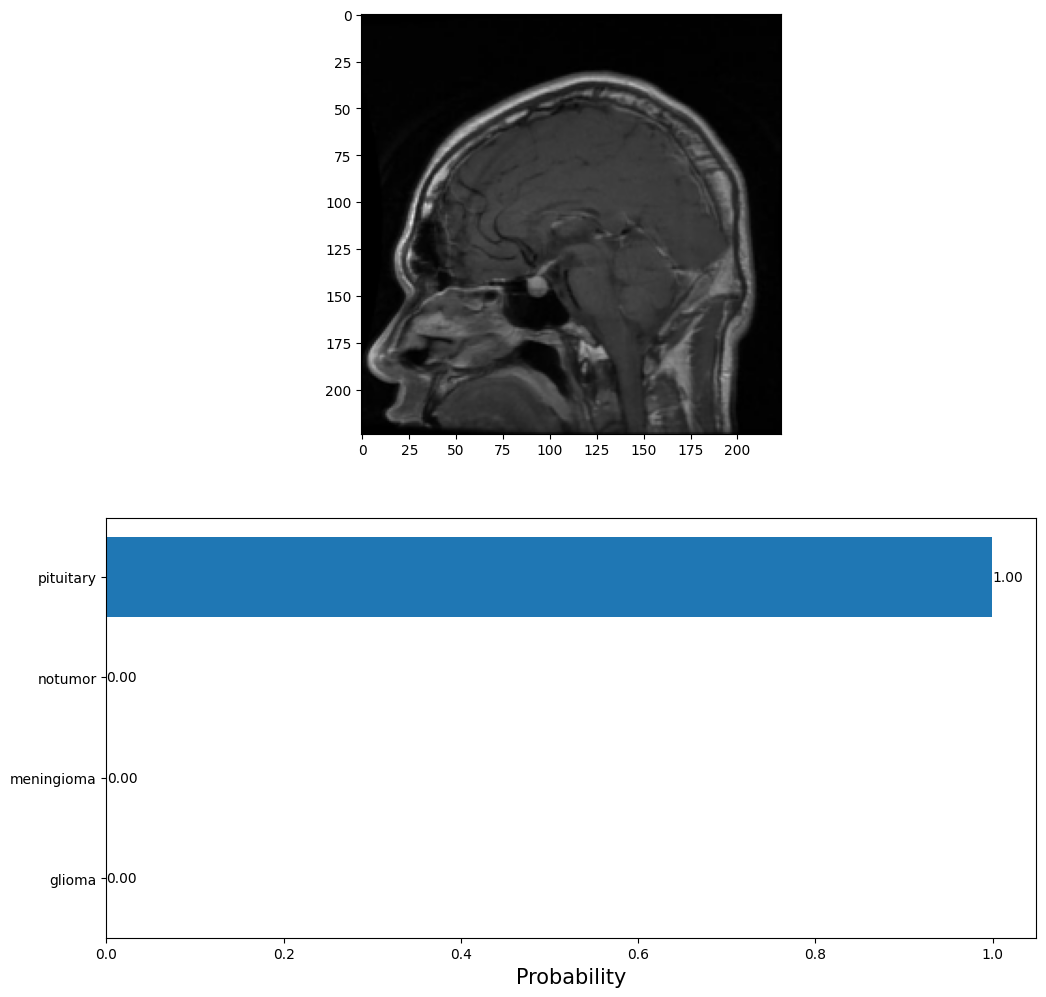

In [51]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/pituitary/Te-piTr_0006.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


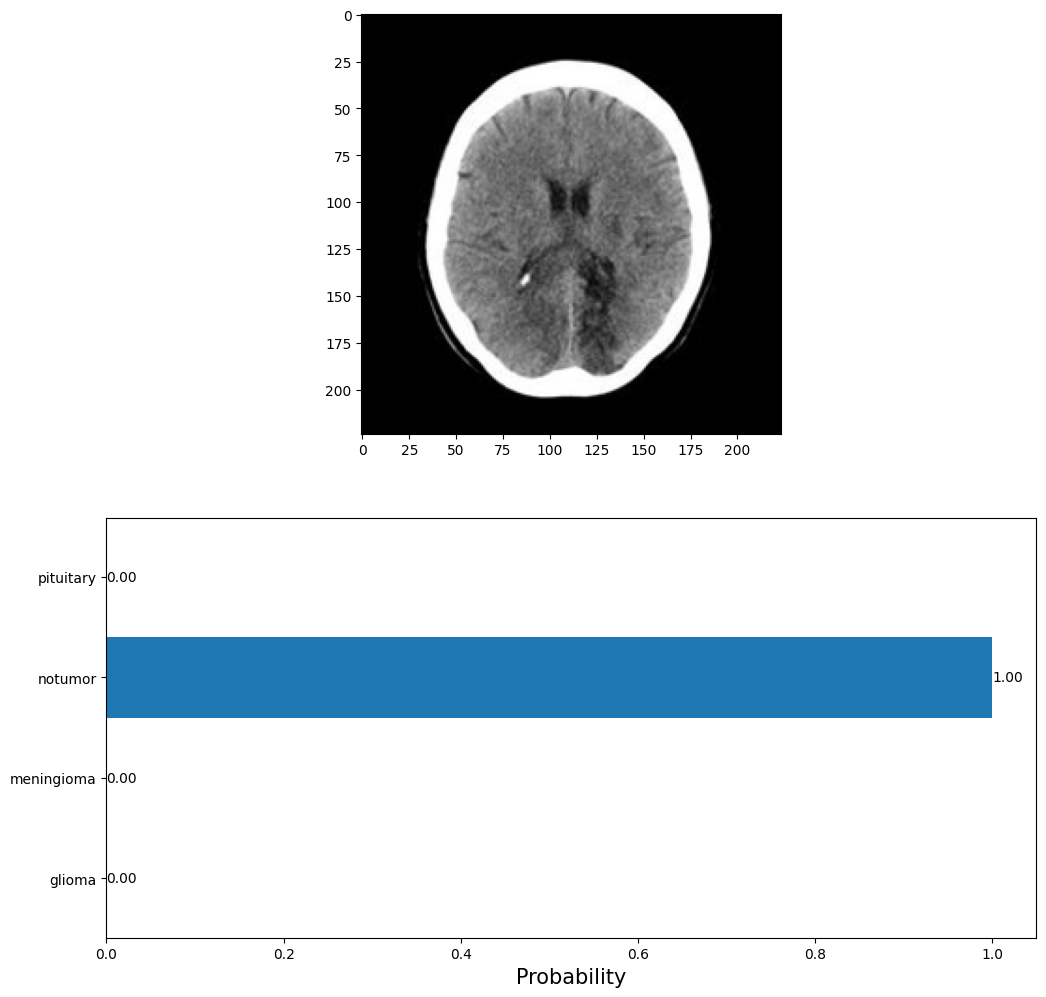

In [53]:
predict('/kaggle/input/brain-tumor-update-dataset/Testing/notumor/Te-no_0012.jpg')